# Importing Libraries

In [1]:
# !pip install scikit-learn

In [2]:
# !pip install seaborn

In [3]:
# !pip install matplotlib

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

## Load Data

In [5]:
df = pd.read_csv("./data/American_Housing_Data_202312092.csv")
print(df.shape)
df.head()
df.info()
df.describe(include="all")

(39981, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39981 entries, 0 to 39980
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Zip Code                 39981 non-null  int64  
 1   Price                    39981 non-null  float64
 2   Beds                     39981 non-null  int64  
 3   Baths                    39981 non-null  int64  
 4   Living Space             39981 non-null  int64  
 5   Address                  39981 non-null  object 
 6   City                     39981 non-null  object 
 7   State                    39981 non-null  object 
 8   Zip Code Population      39981 non-null  int64  
 9   Zip Code Density         39981 non-null  float64
 10  County                   39981 non-null  object 
 11  Median Household Income  39979 non-null  float64
 12  Latitude                 39981 non-null  float64
 13  Longitude                39981 non-null  float64
dtypes: float64

,Zip Code,Price,Beds,Baths,Living Space,Address,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
count,39981.000000,3.998100e+04,39981.000000,39981.000000,39981.000000,39981,39981,39981,39981.000000,39981.000000,39981,39979.000000,39981.000000,39981.000000
unique,NaN,NaN,NaN,NaN,NaN,38827,243,29,NaN,NaN,88,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,331 N 127TH ST E,Mesa,California,NaN,NaN,Maricopa,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,20,894,6056,NaN,NaN,1782,NaN,NaN,NaN
mean,64833.391336,6.227771e+05,3.171682,2.466572,1901.522723,NaN,NaN,NaN,37726.201996,2379.412483,NaN,110837.259861,36.435668,-98.080576
std,25614.601116,9.469793e+05,1.308796,1.323042,1211.307257,NaN,NaN,NaN,18672.647445,2946.574792,NaN,47309.055715,4.446862,15.061145
min,10013.000000,1.800000e+03,1.000000,1.000000,2.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,27475.000000,25.729830,-122.826870
25%,40215.000000,2.650000e+05,3.000000,2.000000,1200.000000,NaN,NaN,NaN,24465.000000,902.400000,NaN,76640.000000,33.239850,-111.636310
50%,74136.000000,3.999000e+05,3.000000,2.000000,1639.000000,NaN,NaN,NaN,35049.000000,1588.700000,NaN,100405.000000,36.166620,-96.839680
75%,85730.000000,6.749900e+05,4.000000,3.000000,2265.000000,NaN,NaN,NaN,46816.000000,2736.800000,NaN,135075.000000,39.283090,-85.656980


## Data Cleaning

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicated rows:")
print(df.duplicated().sum())

Missing values per column:
Zip Code                   0
Price                      0
Beds                       0
Baths                      0
Living Space               0
Address                    0
City                       0
State                      0
Zip Code Population        0
Zip Code Density           0
County                     0
Median Household Income    2
Latitude                   0
Longitude                  0
dtype: int64

Number of duplicated rows:
962


In [7]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()
df["Median Household Income"] = df["Median Household Income"].fillna(df["Median Household Income"].median())

In [8]:
df.shape
df.isnull().sum()

Zip Code                   0
Price                      0
Beds                       0
Baths                      0
Living Space               0
Address                    0
City                       0
State                      0
Zip Code Population        0
Zip Code Density           0
County                     0
Median Household Income    0
Latitude                   0
Longitude                  0
dtype: int64

In [9]:
df.describe()

,Zip Code,Price,Beds,Baths,Living Space,Zip Code Population,Zip Code Density,Median Household Income,Latitude,Longitude
count,39019.000000,3.901900e+04,39019.000000,39019.000000,39019.000000,39019.000000,39019.000000,39019.00000,39019.000000,39019.000000
mean,64870.425818,6.217622e+05,3.171378,2.463748,1899.984187,37697.457905,2367.620880,110786.09949,36.444635,-98.048619
std,25509.952267,9.531520e+05,1.309513,1.325817,1210.783157,18635.871043,2931.105982,47289.87715,4.449218,15.024340
min,10013.000000,1.800000e+03,1.000000,1.000000,2.000000,0.000000,0.000000,27475.00000,25.729830,-122.826870
25%,40218.000000,2.649000e+05,3.000000,2.000000,1201.500000,24440.000000,897.100000,76640.00000,32.996870,-111.634760
50%,74136.000000,3.999000e+05,3.000000,2.000000,1638.000000,35083.000000,1578.800000,100405.00000,36.167890,-96.839430
75%,85716.000000,6.690000e+05,4.000000,3.000000,2265.000000,46816.000000,2727.000000,134948.00000,39.284210,-85.715710
max,98199.000000,3.800000e+07,54.000000,66.000000,74340.000000,116469.000000,58289.600000,900203.00000,47.742370,-73.704510


## Removing Outliers

In [10]:
clean_df = df.copy()

cols_to_clean = ["Price", "Living Space", "Beds", "Baths"]

for col in cols_to_clean:
    lower = clean_df[col].quantile(0.005)
    upper = clean_df[col].quantile(0.995)
    clean_df = clean_df[(clean_df[col] >= lower) & (clean_df[col] <= upper)]
    
clean_df.shape

(38011, 14)

# EDA

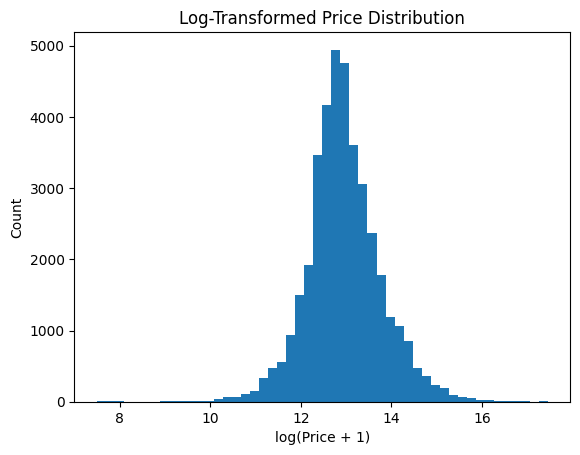

In [11]:
plt.hist(np.log1p(df["Price"]), bins=50)
plt.title("Log-Transformed Price Distribution")
plt.xlabel("log(Price + 1)")
plt.ylabel("Count")
plt.show()


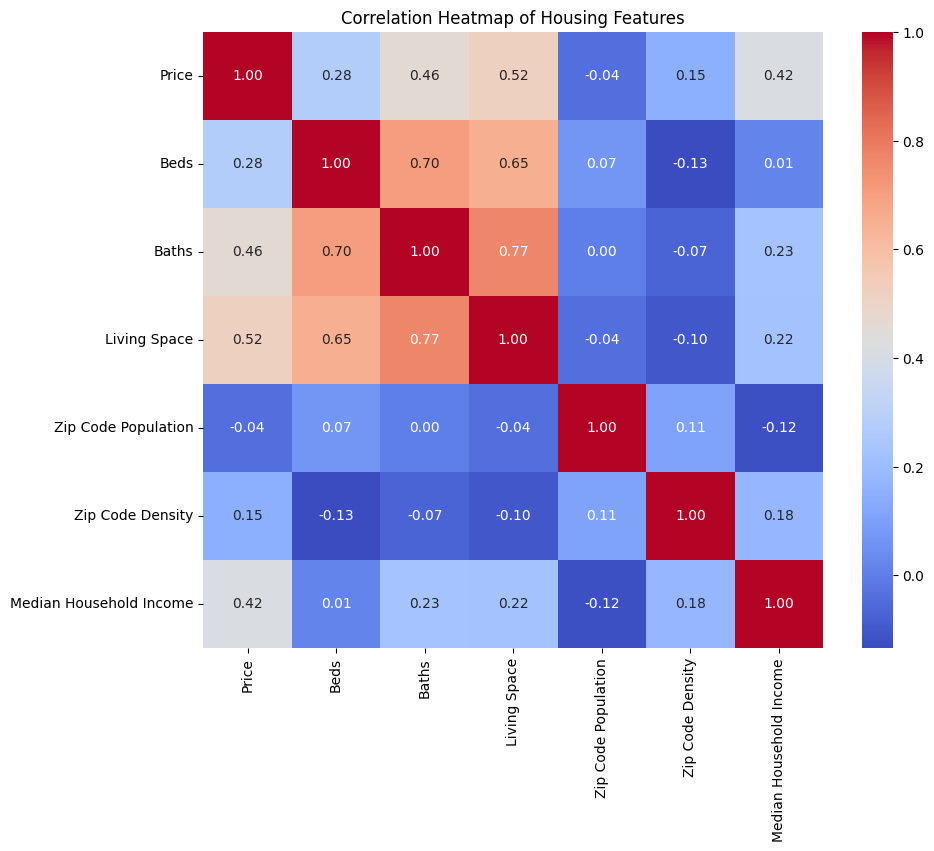

In [12]:
numerical_cols = [
    "Price", "Beds", "Baths", "Living Space",
    "Zip Code Population", "Zip Code Density",
    "Median Household Income"
]

plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Housing Features")
plt.show()

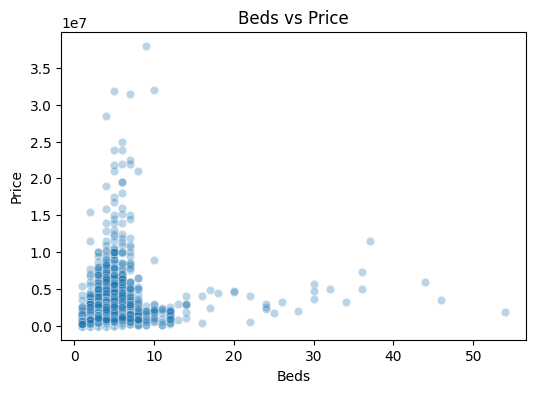

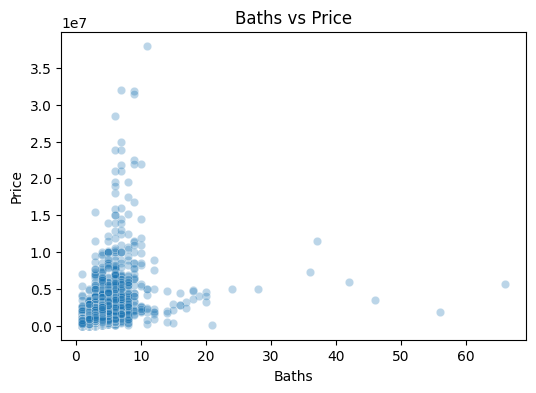

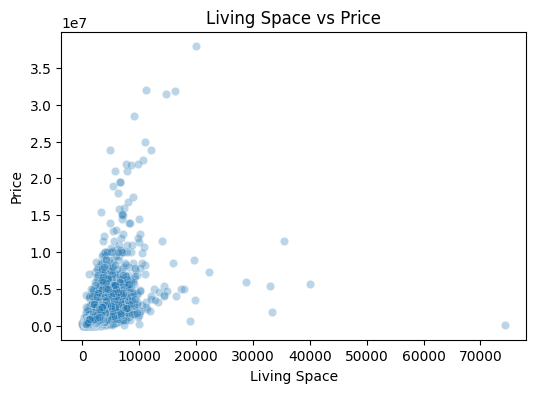

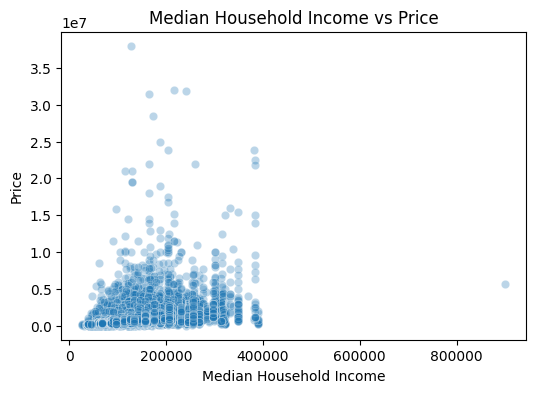

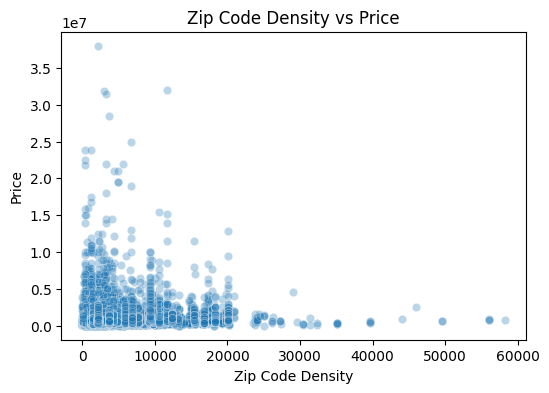

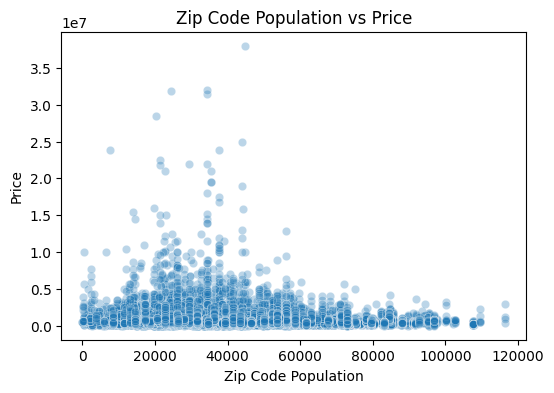

In [13]:
numeric_cols = ["Beds", "Baths", "Living Space", "Median Household Income",
                "Zip Code Density", "Zip Code Population"]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=col, y="Price", data=df, alpha=0.3)
    plt.title(f"{col} vs Price")
    plt.show()

### 15 most expensive cities

In [14]:
df.groupby("City")["Price"].median().sort_values(ascending=False).head(15)

City
Miami Beach          19490000.0
Santa Monica          6524500.0
Beverly Hills         4000000.0
Del Mar               3422000.0
Pacific Palisades     3249000.0
Paradise Valley       3115000.0
La Jolla              2797000.0
West Hollywood        2785000.0
Bennington            2695000.0
Mount Hamilton        2609000.0
Venice                2428500.0
Sherman Oaks          2199000.0
Encino                2062500.0
Wake Forest           1999000.0
Studio City           1998000.0
Name: Price, dtype: float64

### 15 most expensive counties

In [15]:
df.groupby("County")["Price"].median().sort_values(ascending=False).head(15)

County
San Francisco    1295000.0
Santa Clara      1149999.5
Union             999500.0
Los Angeles       999000.0
Hays              925000.0
San Diego         899999.0
King              829925.0
Oldham            787500.0
New York          760000.0
Alameda           758888.0
Kings             758000.0
Nassau            750000.0
Washington        749990.0
Miami-Dade        729000.0
Richmond          710000.0
Name: Price, dtype: float64

# Price Prediction Model

In [16]:
features = ["Beds", "Baths", "Living Space", "Zip Code Population",
            "Zip Code Density", "Median Household Income"]
X = df[features]
y = df["Price"]

In [17]:
df_model = df.copy()

### Encoding categorical features (City, County, State)

In [19]:
df_model = pd.get_dummies(
    df_model,
    columns=["City", "County", "State"],
    drop_first=True
)

In [18]:
df_model = df_model.drop(columns=["Address", "Zip Code"], errors="ignore")

### X model and Y

In [20]:
y = df_model["Price"]
X_model = df_model.drop("Price", axis=1)

In [ ]:
### Scaling numeric columns

In [21]:
num_cols = [
    "Beds", "Baths", "Living Space", 
    "Zip Code Population", "Zip Code Density",
    "Median Household Income", "Latitude", "Longitude"
]

scaler = StandardScaler()
X_model[num_cols] = scaler.fit_transform(X_model[num_cols])

In [ ]:
### Train Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)

## Random Forest Regressor (with Hyperparameter Tuning)

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
Best CV R²: 0.733468059730691


In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    **grid.best_params_,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred_rf = rf.predict(X_test)

### Actual vs Predicted Plot

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

NameError: name 'y_pred' is not defined

<Figure size 600x600 with 0 Axes>

### Feature Importance Plot

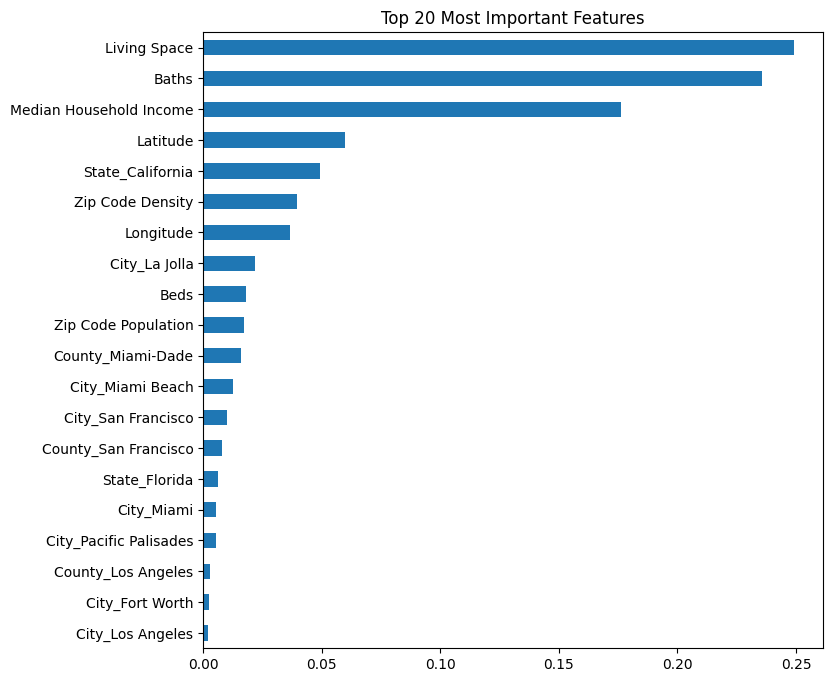

In [28]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top20 = importances.sort_values().tail(20)

plt.figure(figsize=(8,8))
top20.plot(kind="barh")
plt.title("Top 20 Most Important Features")
plt.show()

## XGBoost Regressor (with Hyperparameter Tuning)

In [31]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [32]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

### Train XGBoost regressor

In [33]:
xgb_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [ ]:
### GridSearchCV for XGB

In [34]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

In [35]:
xgb_grid.fit(X_train, y_train)

print("Best XGBoost Parameters:", xgb_grid.best_params_)
print("Best CV R²:", xgb_grid.best_score_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best XGBoost Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best CV R²: 0.7182233884786603


### Final Tuned XGBoost Model

In [36]:
best_xgb = XGBRegressor(
    **xgb_grid.best_params_,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Predictions

### Evaluation Metrics

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{name}")
    print(f"  MAE : {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  MAPE: {mape:,.2f}%")
    print()

# Random Forest (tuned)
evaluate_model("Random Forest (tuned)", y_test, y_pred_rf)

# XGBoost (tuned)
evaluate_model("XGBoost (tuned)", y_test, y_pred_xgb)

r2_rf = r2_score(y_test, y_pred_rf)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"R² Random Forest (tuned): {r2_rf:.4f}")
print(f"R² XGBoost (tuned)     : {r2_xgb:.4f}")

Random Forest (tuned)
  MAE : 151,609.60
  RMSE: 576,811.49
  MAPE: 34.87%



NameError: name 'y_pred_xgb' is not defined

### Actual vs Predicted

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost: Actual vs Predicted Price")
plt.show()

NameError: name 'y_pred_xgb' is not defined

<Figure size 600x600 with 0 Axes>

### *Summary *

This project analyzes U.S. housing data and builds machine learning models to predict home prices.

*Data Cleaning & Preparation*

Removed 962 duplicate rows and filled missing values using median imputation.

Trimmed extreme outliers in key columns (Price, Living Space, Beds, Baths).

Performed one-hot encoding for City, County, and State.

Standardized numerical features for model training.

*Exploratory Analysis*

Log-transformed price distribution to reduce skew.

Correlation analysis showed that Living Space, Baths, and Median Household Income are strongly linked to Price.

Identified the most expensive cities and counties (e.g., Miami Beach, Beverly Hills, San Francisco).

*Modeling*

Two models were trained with GridSearchCV hyperparameter tuning:

*Random Forest (Tuned)*

MAE: ~151k

RMSE: ~578k

MAPE: ~34.8%

R²: 0.73

*XGBoost (Tuned)*

MAE: ~160k

RMSE: ~592k

MAPE: ~36.9%

R²: 0.6863

Random Forest performed slightly better overall.

*Key Insights*

Home size, bathroom count, neighborhood income, and location indicators have the strongest impact on price.

Both models underpredict very high-end luxury homes due to natural data variability.